<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/03_pytorch_computer_vision_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pytorch Computer Vision

## 0. Computer vision libraries in Pytorch

* [`torchvision`] - base domain for computer vision in pytorch
* `torchvision.datasets` - get datasets and data loading fuctions for computer vision
* `torchvision.models` - get pretrained computer vision models that u can leverage for your own problems
* `torchvision.transforms` - functions for manipulating your vision data (images) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - Base dataset class for Pytorch
* `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset.

In [1]:
# import pytorch
import torch
from torch import nn

# import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib for visualization
import matplotlib.pyplot as plt

#check version
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


 ## 1. Getting a dataset.
 the dataset we will be using is FashionMNIST from torchvision datasets

In [2]:
# Setup Training data
train_data = torchvision.datasets.FashionMNIST(
    root="data", # where to download the data to?
    train=True, #do we want the training dataset?
    download=True, # do we want to download yes/no?
    transform = torchvision.transforms.ToTensor(),#how do we want to transform image to tensor?
    target_transform= None #how do we want to transform the labels/targets?
)
test_data =torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.93MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


In [3]:
len(train_data),len(test_data)

(60000, 10000)

In [4]:
#see the first training example
image,label = train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx =train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

##1.1 Check the input and output shapes of data

In [7]:
#check the shaoe of our image
image.shape,class_name[label]
#colorchannel,height,width. label

(torch.Size([1, 28, 28]), 'Ankle boot')

## 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])
Label: 9


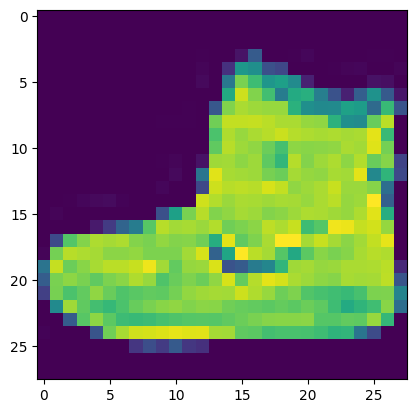

In [8]:
import matplotlib.pyplot as plt
image,label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")
plt.imshow(image.squeeze())

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

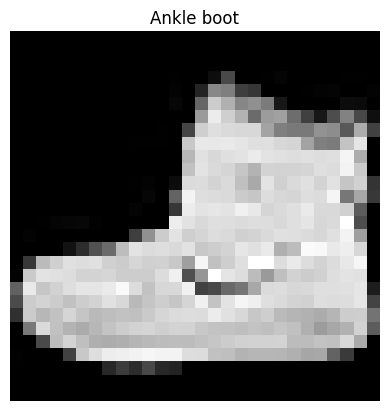

In [9]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_name[label])
plt.axis(False)

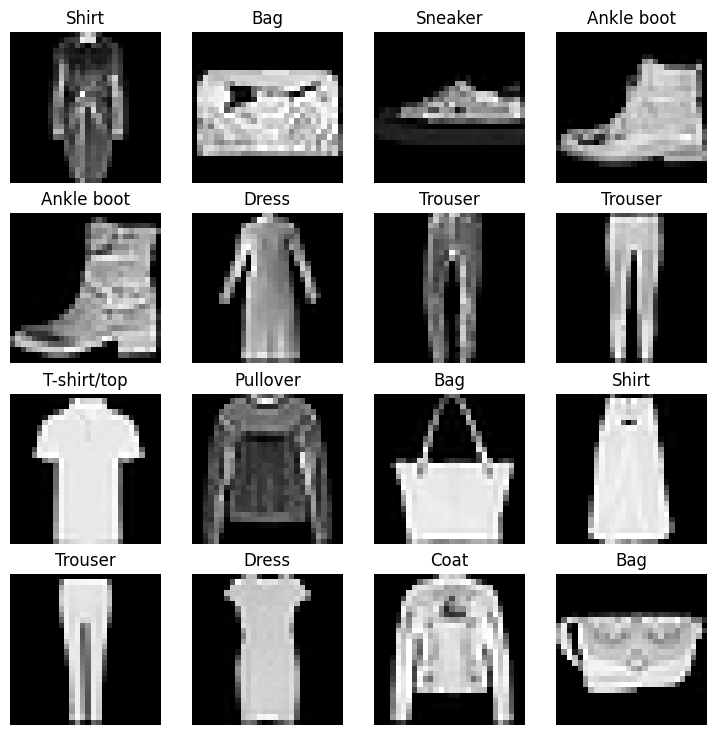

In [10]:
#plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
row,col=4,4
for i in range (1,row*col+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  image ,label = train_data[random_idx]
  fig.add_subplot(row,col,i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.axis(False)
  plt.title(class_name[label])

Do you think these item of clothing(images) could be modified with pure linear lines? Or do you think we will need non-linearities

## 2. Prepare DataLoader

Right now, our data is in the form of Pytorch datasets

DataLoader turns our dataset into a python iterable

More specifically, we want to turn our data into batches

Why would we do this?

1. It is more computationally efficient, as in your computing hardware may not be able to look (store in memory) at 60000 images in one hit. So we break it down to 32 images at atime (btch size of 2).
2. It gives our neural network more chances to update its gradient per epoch.


In [11]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE =32

# Turn datasets into iterable (batches)
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size = BATCH_SIZE,
                             shuffle =False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7df6b1eb6290>,
 <torch.utils.data.dataloader.DataLoader at 0x7df6b1d9b6d0>)

In [12]:
#lets checkout what we created
print(f"DataLoader: {train_dataloader,test_dataloader}\n")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}\n")
print(f"Length of test dataloader: {len(test_dataloader)}\n")

DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x7df6b1eb6290>, <torch.utils.data.dataloader.DataLoader object at 0x7df6b1d9b6d0>)

Length of train dataloader: 1875 batches of 32

Length of test dataloader: 313



In [13]:
#check out whats inside the training dataloader
train_features_batch , train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape , train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Imag size: torch.Size([1, 28, 28])
label: 5,label size:torch.Size([])


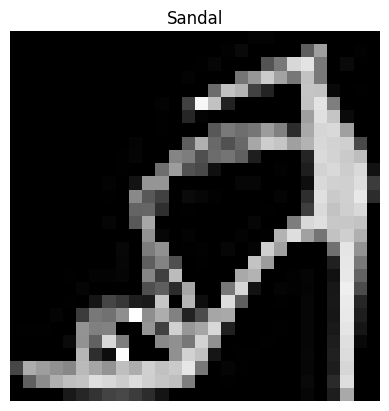

In [14]:
# visualize
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_name[label])
plt.axis(False)
print(f"Imag size: {img.shape}")
print(f"label: {label},label size:{label.shape}")

## 3. Model_0 :build a model

when starting to build a series of machine learning modelling experiments, its best practice to start with a baseline model.

A baseline model is a simple model you will try and improve upon with subsequent models/experiments.

In other words: start simply and add complexity when necessary


In [15]:
# create a flatten layer

flattend_model = nn.Flatten()

#get a single sample
x=train_features_batch[0]
#flatten the ssingle sample
output = flattend_model(x)
print(f"shape before flattening:{x.shape}")
print(f"shape after flattening:{output.shape}")


shape before flattening:torch.Size([1, 28, 28])
shape after flattening:torch.Size([1, 784])


In [16]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack =nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
    )
  def forward(self,x):
      return self.layer_stack(x)

In [17]:
torch.manual_seed(42)

#setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape=28*28, #this is 28*28
    hidden_units=10,#how many units in hidden layer
    output_shape=len(class_name)
)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [18]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x).shape

torch.Size([1, 10])

In [19]:
 model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss function, optimizer and evaluation metrics

* Loss function - since we are working with multiclass data our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer `torch.opitm.SGD()` (stochastic gradient descent)
* Evaluation metric -since we are working on a classification problem, lets use accuracy as our evaluation metrics

In [20]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [21]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### 3.2 Creating function to time our experiments

Machine Learning is very experimental

Two of the main things you will often want to track are:
1. Models performace (loss and accuracy)
2. how fast it runs

In [22]:
from timeit import default_timer as timer
def print_train_time(start:float,
                     end:float,
                     device:torch.device =None):
  """prints difference between start and end time."""
  total_time =end-start
  print(f"train time on {device}: {total_time:.3f} seconds")
  return total_time

In [23]:
start_time = timer()
##sdkfbfkeb
end_time = timer()
print_train_time(start=start_time,end=end_time,device=None)

train time on None: 0.000 seconds


4.7323000003984816e-05

### 3. Creating a training loop and training our model on batches data

1. Loop through epochs
2. Loop through training batches , perform training steps , calculate the train loss "per batch"
3. Loop through testing batches, perform testing steps , calculate the test loss "per batch"
4. print out what is happening
5. Time it all for fun

In [24]:
# import tqdm for progres bar
from tqdm.auto import tqdm
#set the seed and start the timer
torch.manual_seed(42)
train_time_starts_on_cpu =timer()
#set the numberr of epochs (we will keep them loww for fast training)
epochs = 3
#create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"epoch:{epoch}\n------")
  ###training
  train_loss =0
  # add a loop through the training batches
  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()
    #1 forward pass
    y_pred=model_0(X)
    #2Cal loss
    loss = loss_fn(y_pred,y)
    train_loss+=loss
    #3 optimizer zero grad
    optimizer.zero_grad()
    #4 back propagation
    loss.backward()
    #5 optimizer
    optimizer.step()

    #print out
    if batch %400 ==0:
      print(f"Looked at {batch *len(X)}/{len(train_dataloader.dataset)} samples.")

  #divide total train loss by length of train dataloader
  train_loss/=len(train_dataloader)

  ### testing
  test_loss , test_acc =0,0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      test_pred=model_0(X_test)
      test_loss+=loss_fn(test_pred,y_test)
      test_acc += accuracy_fn(y_true=y_test,
                             y_pred=test_pred.argmax(dim=1))
    # calculate the test los average per batch
    test_loss/=len(test_dataloader)

    #calculate the test acc average per batch
    test_acc/= len(test_dataloader)

  print(f"\n Train loss : {train_loss:.4f} | test loss : {test_loss:.4f},test acc: {test_acc:.4f}%")

#cal training time
train_time_ends_on_cpu = timer()
total_train_time_model_0 = print_train_time(start = train_time_starts_on_cpu,
                                            end=train_time_ends_on_cpu,
                                            device = str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

 Train loss : 0.5904 | test loss : 0.5095,test acc: 82.0387%
epoch:1
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

 Train loss : 0.4763 | test loss : 0.4799,test acc: 83.1969%
epoch:2
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

 Train loss : 0.4550 | test loss : 0.4766,test acc: 83.4265%
train time on cpu: 24.557 seconds


## 4. make predictions and get model 0 results

In [25]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.dataloader,
               loss_fn:torch.nn.Module,
               accuracy_fn):
  """returns a dictionary conataining the results of model predicting on data_loader"""
  loss,acc =0,0
  model_0.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      #make prediction
      y_pred =model(X)

      #accumulate the loss and acc values per batch
      loss += loss_fn(y_pred,y)
      acc += accuracy_fn(y_true =y,
                         y_pred=y_pred.argmax(dim=1))

    #scale loss and acc to find the average loss/acc per batch
    loss /=len(data_loader)
    acc /=len(data_loader)

  return {"model_name":model.__class__.__name__,#only workswhen model is created using a class
          "model_loss":loss.item(),
          "model_acc":acc}
#calculate model 0 results n test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [26]:
## 5. Setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1:Building a better model with non-linearity

we learned about the power of non linearity in chapter 2.



In [34]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_unit: int,
               output_shape:int):
    super().__init__()
    self.non_linear_layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features=hidden_unit,out_features=output_shape),

        nn.ReLU()
    )
  def forward(self,x):
    return self.non_linear_layers(x)


In [37]:
# Create an instance if model_1
torch.manual_seed(42)
model_1=FashionMNISTModelV1(input_shape=28*28,
                            hidden_unit=10,
                            output_shape=len(class_name)).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

#6.1 loss function and optimizer

In [40]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr=0.1)

### 6.2 functionizing training and evaluation/testing loops

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  """ Performs a training with model trying to learn on data_loader"""
  train_loss,train_acc=0,0

  # Add a loop to loop through the training batches
  for batch (X,y) in enumerate(data_loader):
